In [6]:
import jax
import jax.numpy as jnp
import jax.scipy.linalg
import jax.scipy.stats # Potentially useful, but we implement manually

# Assume SamplingImplBase is defined elsewhere
class SamplingImplBase:
    def __init__(self, *args, **kwargs):
        # Base class initializer placeholder
        pass
    def apply_padding_mask(self, data, masks):
         # Placeholder for user's mask application logic
         # Example: Assuming mask is boolean [N, S] and padding is 0.0 for entropy/logprob
         if masks is None:
             return data # Return unmodified data if no mask

         # Ensure mask is boolean
         masks = masks.astype(jnp.bool_)

         # Try to broadcast mask to data shape
         try:
             # Add trailing dimensions to mask if needed
             mask_ndim_diff = data.ndim - masks.ndim
             if mask_ndim_diff > 0:
                 broadcast_shape = masks.shape + (1,) * mask_ndim_diff
                 masks = jnp.broadcast_to(masks.reshape(broadcast_shape), data.shape)
             elif mask_ndim_diff < 0:
                 # This case is less common, maybe data has extra dims?
                 print(f"Warning: Mask ndim ({masks.ndim}) > data ndim ({data.ndim}). Masking might be incorrect.")
                 # Attempt to broadcast anyway if shapes compatible
                 masks = jnp.broadcast_to(masks, data.shape)
             else:
                 # ndims match, broadcast if necessary (e.g. mask is [N,S,1], data is [N,S,d])
                 masks = jnp.broadcast_to(masks, data.shape)

             # Apply mask (zero out entries where mask is False)
             return jnp.where(masks, data, 0.0)

         except ValueError as e:
             print(f"Warning: Could not broadcast mask shape {masks.shape} to data shape {data.shape}. Error: {e}. Returning unmodified data.")
             return data


class LowRankMVNSampling(SamplingImplBase):
    """
    Implements sampling, log probability, and entropy calculation for a Low-Rank
    Multivariate Normal distribution for joint actions of shape [s, a].
    The distribution models the flattened action vector of size s * a.
    Covariance structure: Sigma = diag(exp(2*log_std)) + V * V^T
    """
    def __init__(self, action_dim: int, batch_size: int, rank_k: int, apply_tanh: bool = True, epsilon: float = 1e-6):
        """
        Initializes the LowRankMVNSampling strategy.

        Args:
            action_dim (int): Dimension 'a' of a single sample.
            batch_size (int): Number of samples 's' per joint action.
            rank_k (int): The rank 'k' for the low-rank covariance approximation.
            apply_tanh (bool): Whether to apply tanh transformation to the output actions.
            epsilon (float): Small value for numerical stability (e.g., clipping, logs).
        """
        super().__init__() # Call base class init

        self.action_dim = action_dim # a
        self.batch_size = batch_size # s (number of samples per action)
        self.rank_k = rank_k         # k
        self.apply_tanh = apply_tanh
        self.epsilon = epsilon

        # Calculate the dimension of the flattened action vector
        self.flat_action_dim = self.batch_size * self.action_dim # d = s * a

        # Calculate the expected size of the network's output logits
        self.expected_logit_size = self.flat_action_dim * (2 + self.rank_k)

        # Constant term for log_prob: d * log(2 * pi)
        self._log_2pi_d = self.flat_action_dim * jnp.log(2 * jnp.pi)
        # Constant term for entropy: 0.5 * d * (1 + log(2 * pi))
        self._entropy_offset = 0.5 * self.flat_action_dim * (1.0 + jnp.log(2.0 * jnp.pi))


        print(f"LowRankMVNSampling initialized: s={self.batch_size}, a={self.action_dim}, k={self.rank_k}")
        print(f"Flattened action dimension (d): {self.flat_action_dim}")
        print(f"Expected network output size per action: {self.expected_logit_size}")
        print(f"Apply tanh: {self.apply_tanh}")


    def sampling_differ(self, act_logits, key, masks):
        """
        Samples actions using a Low-Rank Multivariate Normal distribution.

        Args:
            act_logits: Raw output tensor from the policy network.
                        Expected shape [N, expected_logit_size], where N is the
                        number of parallel environments (JAX batch dim).
            key: JAX random key.
            masks: Optional padding mask (applied AFTER sampling and tanh).

        Returns:
            Sampled actions tensor of shape [N, s, a] (or [N, batch_size, action_dim]).
        """
        N = act_logits.shape[0] # JAX batch size (num environments)

        # --- Sanity Check: Verify network output size ---
        if act_logits.shape[-1] != self.expected_logit_size:
             raise ValueError(f"Network output dimension mismatch! "
                              f"Expected act_logits last dim {self.expected_logit_size}, "
                              f"but got {act_logits.shape[-1]}. Check network definition.")

        # --- 1. Split Network Output into mu, log_std, V ---
        mu = act_logits[..., :self.flat_action_dim]
        log_std = act_logits[..., self.flat_action_dim : 2 * self.flat_action_dim]
        V_flat = act_logits[..., 2 * self.flat_action_dim :]
        V = jnp.reshape(V_flat, (N, self.flat_action_dim, self.rank_k))

        # --- 2. Prepare Distribution Parameters ---
        sqrt_D_diag = jnp.exp(log_std) # Diagonal standard deviations [N, d]

        # --- 3. Generate Noise ---
        key_diag, key_rank = jax.random.split(key)
        z_diag = jax.random.normal(key_diag, shape=(N, self.flat_action_dim)) # [N, d]
        z_rank = jax.random.normal(key_rank, shape=(N, self.rank_k))          # [N, k]

        # --- 4. Compute Sample ---
        diag_contribution = sqrt_D_diag * z_diag  # [N, d]
        rank_contribution = jnp.einsum('Ndk,Nk->Nd', V, z_rank) # [N, d] = V @ z_rank
        action_flat = mu + diag_contribution + rank_contribution # [N, d]

        # --- 5. Reshape and Apply Final Transformation (tanh) ---
        action_pre_tanh = jnp.reshape(action_flat, (N, self.batch_size, self.action_dim)) # [N, s, a]

        if self.apply_tanh:
            acts_tick = jnp.tanh(action_pre_tanh)
        else:
            acts_tick = action_pre_tanh

        # --- 6. Apply Masking (Optional) ---
        # Masking is typically applied to final outputs like actions or logprobs/entropy
        acts_tick = self.apply_padding_mask(acts_tick, masks)

        return acts_tick # Shape [N, s, a]

    def _single_log_det_sigma(self, log_std, V):
        """ Calculates log determinant of Sigma = D + V*V^T for a single instance """
        # log det(Sigma) = log det(D) + log det(I_k + V^T * D^{-1} * V)
        log_det_D = jnp.sum(2 * log_std) # sum log(variances)

        # Efficient calculation of M = V^T * D^{-1} * V
        D_inv_sqrt = jnp.exp(-log_std)        # [d] = 1 / std_dev
        V_scaled = D_inv_sqrt[:, None] * V   # Scale columns of V. Shape [d, k]
        M = V_scaled.T @ V_scaled            # Shape [k, k]
        inner_matrix = jnp.eye(self.rank_k) + M # Shape [k, k]

        # Calculate log det(I + M) using slogdet for stability
        sign, log_det_inner = jnp.linalg.slogdet(inner_matrix)
        log_det_inner = jnp.where(sign > 0, log_det_inner, -jnp.inf) # Handle non-PD cases

        return log_det_D + log_det_inner # Total log determinant

    def _single_log_prob(self, flat_action, mu, log_std, V):
        """
        Calculates log_prob for a single flattened action vector [d].
        Handles tanh correction internally if self.apply_tanh is True.
        """
        # --- Tanh Correction Handling ---
        if self.apply_tanh:
            clipped_action = jnp.clip(flat_action, -1.0 + self.epsilon, 1.0 - self.epsilon)
            x = jnp.arctanh(clipped_action) # Pre-tanh value
            tanh_log_det_jacobian = jnp.sum(jnp.log(1.0 - jnp.square(clipped_action) + self.epsilon))
        else:
            x = flat_action
            tanh_log_det_jacobian = 0.0

        # --- MVN Calculation for 'x' ---
        y = x - mu # Deviation from mean: x - mu. Shape [d]

        # --- Log Determinant ---
        # Reuse helper function
        log_det_Sigma = self._single_log_det_sigma(log_std, V)

        # --- Mahalanobis Distance Calculation ---
        D_inv_sqrt = jnp.exp(-log_std)        # [d]
        V_scaled = D_inv_sqrt[:, None] * V   # Shape [d, k]
        inner_matrix = jnp.eye(self.rank_k) + (V_scaled.T @ V_scaled) # Shape [k, k]

        z = D_inv_sqrt * y       # Shape [d]
        V_scaled_T_z = V_scaled.T @ z # Shape [k]

        try:
            chol_inner = jax.scipy.linalg.cholesky(inner_matrix, lower=True)
            tmp = jax.scipy.linalg.solve_triangular(chol_inner, V_scaled_T_z, lower=True)
            solved_vec = jax.scipy.linalg.solve_triangular(chol_inner.T, tmp, lower=False)
        except jnp.linalg.LinAlgError:
             solved_vec = jax.numpy.linalg.lstsq(inner_matrix, V_scaled_T_z, rcond=None)[0]

        mahalanobis_sq = jnp.dot(z, z) - jnp.dot(V_scaled_T_z, solved_vec)
        mahalanobis_sq = jnp.maximum(0.0, mahalanobis_sq) # Ensure non-negativity

        # --- Combine for Log Probability of 'x' ---
        log_prob_mvn = -0.5 * (mahalanobis_sq + log_det_Sigma + self._log_2pi_d)

        # --- Apply Tanh Correction ---
        log_prob_final = log_prob_mvn - tanh_log_det_jacobian

        return log_prob_final


    def log_prob(self, actions, act_logits):
        """
        Computes the log probability of actions under the Low-Rank MVN distribution
        for batches of trajectories.

        Args:
            actions: The actions taken. Expected shape [N, S, s, a].
                     These are the final actions (potentially tanh-squashed).
            act_logits: Raw output tensor from the policy network. Expected shape
                        [N, S, expected_logit_size] or [N, S, 1, ...].

        Returns:
            Log probabilities for each step. Shape [N, S].
        """
        # --- Input Shape Handling ---
        if act_logits.ndim == 4 and act_logits.shape[2] == 1:
             act_logits = jnp.squeeze(act_logits, axis=2)
        if act_logits.ndim != 3 or act_logits.shape[-1] != self.expected_logit_size:
             raise ValueError(f"Unexpected act_logits shape. Expected [N, S, {self.expected_logit_size}], got {act_logits.shape}")

        N, S = actions.shape[0], actions.shape[1]
        actions_flat = jnp.reshape(actions, (N, S, self.flat_action_dim)) # [N, S, d]

        # --- Parse act_logits ---
        mu = act_logits[..., :self.flat_action_dim] # [N, S, d]
        log_std = act_logits[..., self.flat_action_dim : 2 * self.flat_action_dim] # [N, S, d]
        V_flat = act_logits[..., 2 * self.flat_action_dim :] # [N, S, d*k]
        V = jnp.reshape(V_flat, (N, S, self.flat_action_dim, self.rank_k)) # [N, S, d, k]

        # --- Vectorize the single log_prob calculation ---
        log_prob_calculator_vmapped = jax.vmap( # Map over N
            jax.vmap( # Map over S
                self._single_log_prob, in_axes=(0, 0, 0, 0) # Map over S-dim slices
            ), in_axes=(0, 0, 0, 0) # Map over N-dim slices
        )
        log_probs = log_prob_calculator_vmapped(actions_flat, mu, log_std, V) # [N, S]

        return log_probs

    def entropy(self, act_logits, masks=None):
        """
        Computes the differential entropy of the base Low-Rank MVN distribution
        (before tanh transformation) for batches of trajectories.

        Args:
            act_logits: Raw output tensor from the policy network. Expected shape
                        [N, S, expected_logit_size] or [N, S, 1, ...].
            masks: Optional padding mask to apply to the output entropy (e.g., boolean [N, S]).

        Returns:
            Entropy for each step. Shape [N, S].
        """
         # --- Input Shape Handling ---
        if act_logits.ndim == 4 and act_logits.shape[2] == 1:
             act_logits = jnp.squeeze(act_logits, axis=2)
        if act_logits.ndim != 3 or act_logits.shape[-1] != self.expected_logit_size:
             raise ValueError(f"Unexpected act_logits shape. Expected [N, S, {self.expected_logit_size}], got {act_logits.shape}")

        N, S = act_logits.shape[0], act_logits.shape[1]

        # --- Parse act_logits (only need log_std and V for entropy) ---
        log_std = act_logits[..., self.flat_action_dim : 2 * self.flat_action_dim] # [N, S, d]
        V_flat = act_logits[..., 2 * self.flat_action_dim :] # [N, S, d*k]
        V = jnp.reshape(V_flat, (N, S, self.flat_action_dim, self.rank_k)) # [N, S, d, k]

        # --- Vectorize the log determinant calculation ---
        # Map over N and S dimensions for log_std and V
        log_det_sigma_calculator_vmapped = jax.vmap( # Map over N
            jax.vmap( # Map over S
                self._single_log_det_sigma, in_axes=(0, 0) # Map over S-dim slices
            ), in_axes=(0, 0) # Map over N-dim slices
        )
        log_det_sigmas = log_det_sigma_calculator_vmapped(log_std, V) # Shape [N, S]

        # --- Calculate Entropy ---
        # H(X) = 0.5 * log det(Sigma) + 0.5 * d * (1 + log(2*pi))
        # H(X) = 0.5 * log_det_sigmas + self._entropy_offset
        entropies = 0.5 * log_det_sigmas + self._entropy_offset # Shape [N, S]

        # --- Apply Masking (Optional) ---
        entropies = self.apply_padding_mask(entropies, masks)

        return entropies


# Example Usage (Conceptual - requires actual data)
if __name__ == '__main__':
    # --- Hyperparameters ---
    N_envs = 8
    S_steps = 256
    s_batch = 2 # 's' dimension
    a_dim = 3   # 'a' dimension
    k_rank = 4  # Rank 'k'
    apply_tanh = True
    d_flat = s_batch * a_dim

    # --- Instantiate ---
    sampler = LowRankMVNSampling(action_dim=a_dim, batch_size=s_batch, rank_k=k_rank, apply_tanh=apply_tanh)

    # --- Create Dummy Data ---
    key = jax.random.PRNGKey(0)
    dummy_actions = jax.random.uniform(key, shape=(N_envs, S_steps, s_batch, a_dim), minval=-1.0, maxval=1.0)
    key, subkey = jax.random.split(key)
    # Generate plausible logits (e.g., small means, negative log_stds, small V)
    dummy_logits = jax.random.normal(subkey, shape=(N_envs, S_steps, sampler.expected_logit_size)) * 0.1
    # Ensure log_stds are negative for reasonable std devs
    dummy_logits = dummy_logits.at[..., d_flat:2*d_flat].add(-1.0)
    key, subkey = jax.random.split(key)
    dummy_masks = jax.random.bernoulli(subkey, 0.9, shape=(N_envs, S_steps)) # Example mask


    # --- Calculate Log Probs ---
    try:
        log_p = sampler.log_prob(dummy_actions, dummy_logits)
        print("Log Prob Calculation Successful!")
        print("Output shape:", log_p.shape) # Expected: (8, 256)

        # --- Calculate Entropy ---
        ent = sampler.entropy(dummy_logits, masks=dummy_masks)
        print("\nEntropy Calculation Successful!")
        print("Output shape:", ent.shape) # Expected: (8, 256)
        # Check if masking worked (some values should be 0.0 if mask has False)
        print("Entropy sample (first env, first 10 steps):", ent[0, :10])
        print("Mask sample (first env, first 10 steps):   ", dummy_masks[0, :10])


        # --- Test Sampling ---
        key, subkey = jax.random.split(key)
        # Sample for first step, N environments
        sampled_actions = sampler.sampling_differ(dummy_logits[:, 0, :], subkey, masks=dummy_masks[:, 0])
        print("\nSampling Successful!")
        print("Sampled actions shape:", sampled_actions.shape) # Expected: (8, 2, 3)

    except Exception as e:
        print("\nAn error occurred during calculation or sampling:")
        print(e)
        import traceback
        traceback.print_exc()

LowRankMVNSampling initialized: s=2, a=3, k=4
Flattened action dimension (d): 6
Expected network output size per action: 36
Apply tanh: True
Log Prob Calculation Successful!
Output shape: (8, 256)

Entropy Calculation Successful!
Output shape: (8, 256)
Entropy sample (first env, first 10 steps): [3.236981  3.2220325 2.8068051 2.9273167 2.916667  3.6054306 3.3349566
 3.4228272 3.32408   3.4202957]
Mask sample (first env, first 10 steps):    [ True  True  True  True  True  True  True  True  True  True]

Sampling Successful!
Sampled actions shape: (8, 2, 3)


LowRankMVNSampling initialized: s=1, a=2, k=1
Flattened action dimension (d): 2
Expected network output size per action: 6
Apply tanh: False
2

Sampler instantiated with d=2, k=1, tanh=False

Using fixed distribution parameters (N=1, S=1):
 mu = [ 1.5 -0.5]
 std = [0.5 1.8]

--- Test 1: Visual Sampling vs. Log Probability ---
Generated 10000 samples (pre-tanh). Shape: (10000, 2)
Calculated probability density on grid.


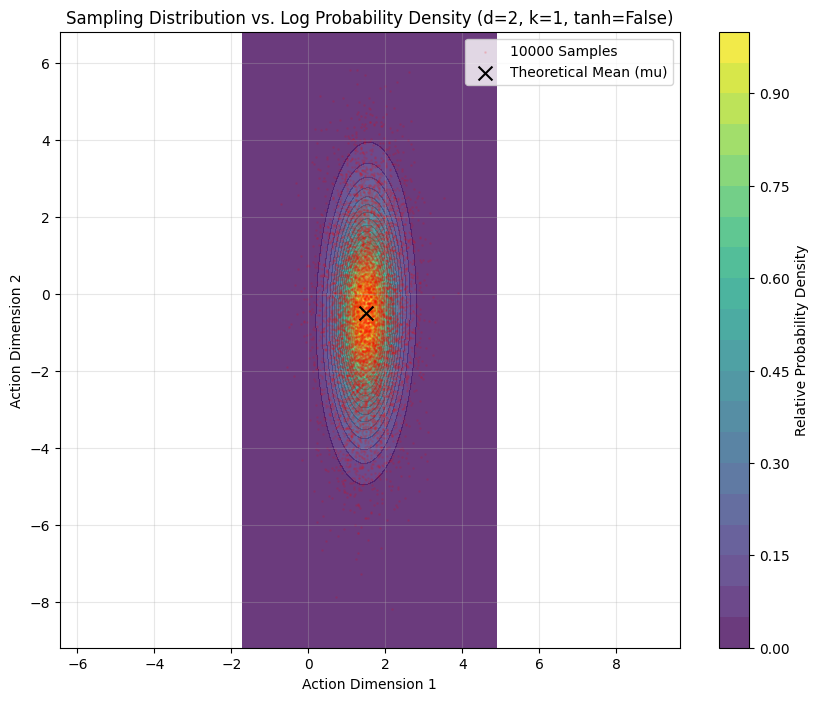


--- Test 2: Entropy Consistency ---
Entropy (Low Variance): -1.7656
Entropy (High Variance): 2.8717
Consistency Check PASSED: Higher variance resulted in higher entropy.

--- Test 3: Entropy Analytic Check (Diagonal Case, k=0) ---
LowRankMVNSampling initialized: s=1, a=2, k=0
Flattened action dimension (d): 2
Expected network output size per action: 4
Apply tanh: False
Entropy (Calculated, k=0): 2.5502
Entropy (Analytic, k=0):   2.5502
Analytic Check PASSED: Calculated entropy matches analytic formula for k=0.

--- Test 4: Sampling Statistics (Mean and Covariance) ---
Theoretical Mean: [ 1.5 -0.5]
Empirical Mean:   [ 1.5109423  -0.53737545]
Theoretical Covariance:
[[0.2830255 0.0435629]
 [0.0435629 3.2974622]]
Empirical Covariance:
[[0.2807362 0.0330644]
 [0.0330644 3.308464 ]]

Mean Check Close: True
Covariance Check Close: True

--- Test 5: Log Prob Boundary Check ---
Skipping boundary check because apply_tanh is False.

--- Test 6: Masking Check ---
Mask:
 [[0 1 1 1 1]
 [1 1 1 1 0]

In [11]:
# %% Import necessary libraries
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns # Optional for nicer plots
import numpy as np # For meshgrid
from functools import partial # For vmapping functions with static args

# %% Import the class (assuming it's saved in low_rank_mvn.py)
# try:
#     import LowRankMVNSampling
#     print("Successfully imported LowRankMVNSampling.")
# except ImportError:
#     print("Error: Could not import LowRankMVNSampling.")
#     print("Please ensure 'low_rank_mvn.py' containing the class is in the same directory.")
#     # Define a dummy class to avoid further errors in the script if needed
#     class LowRankMVNSampling:
#         def __init__(self, *args, **kwargs): pass
#         def sampling_differ(self, *args, **kwargs): pass
#         def log_prob(self, *args, **kwargs): pass
#         def entropy(self, *args, **kwargs): pass

# %% --- Configuration ---
# Distribution parameters
S_BATCH = 1 # Use s=1 for 2D visualization test
A_DIM = 2   # Use a=2 for 2D visualization test (d=2)
K_RANK = 1  # Rank (try varying this)
APPLY_TANH = False # Set to True to test tanh squashing
FLAT_DIM = S_BATCH * A_DIM # d

# Testing parameters
NUM_SAMPLES = 10000 # For statistical tests
GRID_POINTS = 100  # For density plots
N_ENVS = 1 # Number of parallel environments for testing shapes (can increase)
S_STEPS = 1 # Number of time steps for testing shapes (can increase)

# Random key
key = jax.random.PRNGKey(42)

# %% --- Instantiate Sampler ---
sampler = LowRankMVNSampling(
    action_dim=A_DIM,
    batch_size=S_BATCH,
    rank_k=K_RANK,
    apply_tanh=APPLY_TANH
)
print(sampler.action_dim)
print(f"\nSampler instantiated with d={sampler.flat_action_dim}, k={sampler.rank_k}, tanh={sampler.apply_tanh}")

# %% --- Generate Fixed Distribution Parameters (act_logits) ---
key, subkey = jax.random.split(key)
# Example: Centered mean, moderate diagonal std dev, small V component
fixed_mu = jnp.array([1.5, -0.5]) # Shape [d]
fixed_log_std = jnp.log(jnp.array([0.5, 1.8])) # Shape [d] -> stds [0.5, 0.8]
fixed_V = jax.random.normal(subkey, (FLAT_DIM, K_RANK)) * 0.3 # Shape [d, k]

# Combine into act_logits for N=1, S=1
fixed_logits_single = jnp.concatenate([
    fixed_mu,
    fixed_log_std,
    fixed_V.flatten()
])[None, None, :] # Add N and S dimensions -> Shape [1, 1, expected_logit_size]

print(f"\nUsing fixed distribution parameters (N=1, S=1):")
print(f" mu = {fixed_mu}")
print(f" std = {jnp.exp(fixed_log_std)}")
# print(f" V = \n{fixed_V}") # Can be large

# %% --- Test 1: Visual Sampling vs. Log Probability (d=2) ---
print("\n--- Test 1: Visual Sampling vs. Log Probability ---")
if FLAT_DIM != 2:
    print(f"Skipping visual test because dimension d={FLAT_DIM} is not 2.")
else:
    # --- Generate Samples ---
    key, *sample_keys = jax.random.split(key, NUM_SAMPLES + 1)
    sample_keys = jnp.array(sample_keys)

    # Jit the sampling function for speed
    # Note: sampling_differ expects N dim, so use logits[0,0,:] and add N dim back
    @jax.jit
    def sample_one(k):
         # Sample one action (shape [1, s, a]), squeeze N dim out
         # Pass None for mask
         act = sampler.sampling_differ(fixed_logits_single[0], k, masks=None)#, return_pre_tanh=True)
         # Return pre-tanh for plotting the base MVN distribution
         return act[0] # Shape [s, a]

    # Vmap over keys
    samples_pre_tanh = jax.vmap(sample_one)(sample_keys) # Shape [NUM_SAMPLES, s, a]
    # Reshape samples to [NUM_SAMPLES, d] for plotting
    samples_flat = samples_pre_tanh.reshape(NUM_SAMPLES, FLAT_DIM)
    print(f"Generated {NUM_SAMPLES} samples (pre-tanh). Shape: {samples_flat.shape}")

    # --- Calculate Log Prob Density on a Grid ---
    # Determine plot range based on samples
    min_vals = jnp.min(samples_flat, axis=0) - 1.0
    max_vals = jnp.max(samples_flat, axis=0) + 1.0

    # Create grid
    x_grid = np.linspace(min_vals[0], max_vals[0], GRID_POINTS)
    y_grid = np.linspace(min_vals[1], max_vals[1], GRID_POINTS)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_flat = np.vstack([xx.ravel(), yy.ravel()]).T # Shape [GRID_POINTS^2, 2]

    # Reshape grid points to match expected action input [N, S, s, a]
    # Here N=GRID_POINTS^2, S=1, s=S_BATCH, a=A_DIM
    grid_actions = jnp.array(grid_flat).reshape(GRID_POINTS*GRID_POINTS, 1, S_BATCH, A_DIM)

    # Prepare corresponding logits (repeat the fixed logits)
    grid_logits = jnp.repeat(fixed_logits_single, GRID_POINTS*GRID_POINTS, axis=0) # Shape [GRID_POINTS^2, 1, expected_logit_size]

    # Jit the log_prob function
    # Note: log_prob expects [N, S, ...] inputs
    @jax.jit
    def calculate_log_probs(actions, logits):
        return sampler.log_prob(actions, logits)

    # Calculate log probs
    log_probs_grid = calculate_log_probs(grid_actions, grid_logits) # Shape [GRID_POINTS^2, 1]
    log_probs_grid = log_probs_grid.flatten() # Shape [GRID_POINTS^2]
    # Convert to probability density (handle potential underflow/overflow)
    probs_grid = jnp.exp(log_probs_grid - jnp.max(log_probs_grid)) # Normalize peak to 1 for visualization
    probs_grid_reshaped = probs_grid.reshape(GRID_POINTS, GRID_POINTS)
    print("Calculated probability density on grid.")

    # --- Plotting ---
    plt.figure(figsize=(10, 8))
    # Plot density contours
    contour = plt.contourf(xx, yy, probs_grid_reshaped, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(contour, label='Relative Probability Density')
    # Overlay samples
    plt.scatter(samples_flat[:, 0], samples_flat[:, 1], s=1, alpha=0.1, color='red', label=f'{NUM_SAMPLES} Samples')
    # Plot theoretical mean
    plt.scatter(fixed_mu[0], fixed_mu[1], marker='x', s=100, color='black', label='Theoretical Mean (mu)')

    plt.title(f'Sampling Distribution vs. Log Probability Density (d=2, k={K_RANK}, tanh={APPLY_TANH})')
    plt.xlabel('Action Dimension 1')
    plt.ylabel('Action Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# %% --- Test 2: Entropy Consistency ---
print("\n--- Test 2: Entropy Consistency ---")
key, subkey1, subkey2 = jax.random.split(key, 3)

# Low variance parameters
logits_low_var = jnp.concatenate([
    jnp.zeros(FLAT_DIM), # Zero mean
    jnp.log(jnp.ones(FLAT_DIM) * 0.1), # Small std dev (0.1)
    (jax.random.normal(subkey1, (FLAT_DIM, K_RANK)) * 0.01).flatten() # Very small V
])[None, None, :] # Shape [1, 1, ...]

# High variance parameters
logits_high_var = jnp.concatenate([
    jnp.zeros(FLAT_DIM), # Zero mean
    jnp.log(jnp.ones(FLAT_DIM) * 1.0), # Larger std dev (1.0)
    (jax.random.normal(subkey2, (FLAT_DIM, K_RANK)) * 0.5).flatten() # Larger V
])[None, None, :] # Shape [1, 1, ...]

# Jit entropy calculation
@jax.jit
def calculate_entropy(logits):
    # Pass None for mask
    return sampler.entropy(logits, masks=None)

entropy_low = calculate_entropy(logits_low_var)[0, 0] # Extract scalar value
entropy_high = calculate_entropy(logits_high_var)[0, 0]

print(f"Entropy (Low Variance): {entropy_low:.4f}")
print(f"Entropy (High Variance): {entropy_high:.4f}")

try:
    assert entropy_high > entropy_low
    print("Consistency Check PASSED: Higher variance resulted in higher entropy.")
except AssertionError:
    print("Consistency Check FAILED: Higher variance did NOT result in higher entropy!")

# %% --- Test 3: Entropy Analytic Check (Diagonal Case, k=0) ---
print("\n--- Test 3: Entropy Analytic Check (Diagonal Case, k=0) ---")
# Instantiate sampler with k=0
sampler_k0 = LowRankMVNSampling(
    action_dim=A_DIM,
    batch_size=S_BATCH,
    rank_k=0, # Set rank to 0
    apply_tanh=APPLY_TANH # Tanh doesn't affect base entropy calculation
)

# Define parameters (V is now empty)
fixed_mu_k0 = jnp.array([0.1, 0.2])[:FLAT_DIM] # Use correct dimension
fixed_log_std_k0 = jnp.log(jnp.array([0.5, 1.5]))[:FLAT_DIM] # Use correct dimension
logits_k0 = jnp.concatenate([fixed_mu_k0, fixed_log_std_k0])[None, None, :] # Shape [1, 1, d*2]

# Calculate entropy using the class method
entropy_calculated_k0 = sampler_k0.entropy(logits_k0)[0, 0]

# Calculate entropy analytically for diagonal MVN
# H = 0.5 * log det(D) + 0.5 * d * (1 + log(2*pi))
# H = 0.5 * sum(2*log_std) + sampler_k0._entropy_offset
# H = sum(log_std) + sampler_k0._entropy_offset
analytic_entropy_k0 = jnp.sum(fixed_log_std_k0) + sampler_k0._entropy_offset

print(f"Entropy (Calculated, k=0): {entropy_calculated_k0:.4f}")
print(f"Entropy (Analytic, k=0):   {analytic_entropy_k0:.4f}")

try:
    assert jnp.allclose(entropy_calculated_k0, analytic_entropy_k0)
    print("Analytic Check PASSED: Calculated entropy matches analytic formula for k=0.")
except AssertionError:
    print("Analytic Check FAILED: Calculated entropy does NOT match analytic formula for k=0!")

# %% --- Test 4: Sampling Statistics (Mean and Covariance) ---
print("\n--- Test 4: Sampling Statistics (Mean and Covariance) ---")
# Reuse fixed_logits_single from Test 1

# --- Generate many samples (pre-tanh) ---
key, *sample_keys = jax.random.split(key, NUM_SAMPLES + 1)
sample_keys = jnp.array(sample_keys)

# Jit the sampling function to return pre-tanh
@jax.jit
def sample_one_pre_tanh(k):
     act = sampler.sampling_differ(fixed_logits_single[0], k, masks=None)#, return_pre_tanh=True)
     return act[0] # Shape [s, a]

samples_pre_tanh = jax.vmap(sample_one_pre_tanh)(sample_keys) # Shape [NUM_SAMPLES, s, a]
samples_flat = samples_pre_tanh.reshape(NUM_SAMPLES, FLAT_DIM) # Shape [NUM_SAMPLES, d]

# --- Calculate Empirical Stats ---
empirical_mean = jnp.mean(samples_flat, axis=0)
empirical_cov = jnp.cov(samples_flat, rowvar=False)

# --- Calculate Theoretical Stats ---
theoretical_mean = fixed_mu
# Sigma = D + V*V^T
D = jnp.diag(jnp.exp(2 * fixed_log_std))
VVT = fixed_V @ fixed_V.T
theoretical_cov = D + VVT

print(f"Theoretical Mean: {theoretical_mean}")
print(f"Empirical Mean:   {empirical_mean}")
print(f"Theoretical Covariance:\n{theoretical_cov}")
print(f"Empirical Covariance:\n{empirical_cov}")

# --- Compare ---
mean_close = jnp.allclose(theoretical_mean, empirical_mean, atol=0.1) # Tolerance depends on NUM_SAMPLES
cov_close = jnp.allclose(theoretical_cov, empirical_cov, atol=0.1)   # Tolerance depends on NUM_SAMPLES

print(f"\nMean Check Close: {mean_close}")
print(f"Covariance Check Close: {cov_close}")
if not mean_close or not cov_close:
    print("Note: Statistical tests require large NUM_SAMPLES for high accuracy.")

# %% --- Test 5: Log Prob Boundary Check (if apply_tanh=True) ---
print("\n--- Test 5: Log Prob Boundary Check ---")
if not APPLY_TANH:
    print("Skipping boundary check because apply_tanh is False.")
else:
    # Create actions near boundaries
    actions_near_boundary = jnp.array([
        [-0.9999, 0.9999],
        [ 0.9999, -0.9999]
    ])[:FLAT_DIM] # Ensure correct dimension if d=1

    if actions_near_boundary.shape[0] != FLAT_DIM:
         print(f"Skipping boundary check for d={FLAT_DIM}") # Only check for d=2 easily
    else:
        actions_boundary_reshaped = actions_near_boundary.reshape(1, 1, S_BATCH, A_DIM) # Shape [1, 1, s, a]

        # Calculate log_prob
        log_prob_boundary = sampler.log_prob(actions_boundary_reshaped, fixed_logits_single)
        print(f"Log prob for actions near +/-1: {log_prob_boundary[0, 0]:.4f}")

        try:
            assert jnp.isfinite(log_prob_boundary)
            print("Boundary Check PASSED: Log prob is finite for actions near +/-1.")
        except AssertionError:
            print("Boundary Check FAILED: Log prob is NaN or Inf for actions near +/-1!")

# %% --- Test 6: Masking Check ---
print("\n--- Test 6: Masking Check ---")
N_mask_test = 4
S_mask_test = 5
key, subkey = jax.random.split(key)
mask_test = jax.random.bernoulli(subkey, 0.7, shape=(N_mask_test, S_mask_test)) # Boolean mask [N, S]

# Generate logits for multiple envs/steps
key, subkey = jax.random.split(key)
logits_mask_test = jax.random.normal(subkey, (N_mask_test, S_mask_test, sampler.expected_logit_size)) * 0.1
logits_mask_test = logits_mask_test.at[..., FLAT_DIM:2*FLAT_DIM].add(-1.0) # Negative log_std

# Calculate entropy with mask
entropy_masked = sampler.entropy(logits_mask_test, masks=mask_test)

# Calculate entropy without mask
entropy_unmasked = sampler.entropy(logits_mask_test, masks=None)

print("Mask:\n", mask_test.astype(int))
print("Entropy (Unmasked):\n", entropy_unmasked)
print("Entropy (Masked):\n", entropy_masked)

# Check if entropy is zero where mask is False
masked_correctly = jnp.all((entropy_masked == 0.0) == (~mask_test))

try:
    assert masked_correctly
    print("\nMasking Check PASSED: Entropy is zero where mask is False.")
except AssertionError:
    print("\nMasking Check FAILED: Entropy is NOT zero where mask is False!")

# Test masking for log_prob (requires dummy actions)
key, subkey = jax.random.split(key)
actions_mask_test = jax.random.uniform(key, (N_mask_test, S_mask_test, S_BATCH, A_DIM), minval=-0.9, maxval=0.9)
logprob_masked = sampler.log_prob(actions_mask_test, logits_mask_test)
# Apply mask manually for comparison
logprob_masked_manual = jnp.where(mask_test, logprob_masked, 0.0)

# Note: log_prob itself doesn't take the mask, the loss function usually applies it.
# Let's test if apply_padding_mask works as expected on a generic array
generic_data = jnp.ones((N_mask_test, S_mask_test))
generic_masked = sampler.apply_padding_mask(generic_data, mask_test)
masking_generic_correct = jnp.all((generic_masked == 0.0) == (~mask_test))
print(f"\nGeneric Masking Correct: {masking_generic_correct}")


print("\n--- All Tests Completed ---")



In [ ]:
# 1. Add a helper function for pre-tanh sampling (for a single instance)
def _sample_pre_tanh(self, mu, log_std, V, key):
    """ Samples a single pre-tanh action vector x ~ MVN(mu, D+VV^T) """
    key_diag, key_rank = jax.random.split(key)
    z_diag = jax.random.normal(key_diag, shape=(self.flat_action_dim,)) # [d]
    z_rank = jax.random.normal(key_rank, shape=(self.rank_k,))          # [k]

    sqrt_D_diag = jnp.exp(log_std) # [d]
    diag_contribution = sqrt_D_diag * z_diag  # [d]
    rank_contribution = jnp.einsum('dk,k->d', V, z_rank) # [d] = V @ z_rank
    action_flat = mu + diag_contribution + rank_contribution # [d]
    return action_flat # This is the pre-tanh sample 'x'

# 2. Add a helper function for the MC estimation of the expected log-det-Jacobian
def _mc_expected_log_det_jacobian(self, mu, log_std, V, key, num_samples):
    """ Calculates E[ sum log(1 - tanh^2(X)) ] via Monte Carlo """
    # Generate unique keys for each sample
    sample_keys = jax.random.split(key, num_samples)

    # Vmap the pre-tanh sampling over the keys
    # sample_pre_tanh_vmapped = jax.vmap(self._sample_pre_tanh, in_axes=(None, None, None, 0)) # JAX < 0.4.14 syntax
    sample_pre_tanh_vmapped = jax.vmap(partial(self._sample_pre_tanh, mu, log_std, V), in_axes=(0)) # JAX >= 0.4.14 syntax
    
    # Generate samples
    x_samples = sample_pre_tanh_vmapped(sample_keys) # Shape [num_samples, d]

    # Calculate tanh(x) for each sample
    tanh_x_samples = jnp.tanh(x_samples) # Shape [num_samples, d]

    # Calculate log(1 - tanh^2(x)) for each element and sum over dimension d
    # log_det_jacobian_samples = jnp.sum(jnp.log(1.0 - jnp.square(tanh_x_samples) + self.epsilon), axis=-1) # Shape [num_samples]
    
    # Numerically stabler version: sum( -2 * log(cosh(x)) )
    log_cosh_x = jnp.abs(x_samples) + jnp.log1p(jnp.exp(-2.0 * jnp.abs(x_samples))) - jnp.log(2.0)
    log_det_jacobian_samples = -2.0 * jnp.sum(log_cosh_x, axis=-1) # Shape [num_samples]


    # Return the mean over the samples
    return jnp.mean(log_det_jacobian_samples)


# 3. Modify the entropy function
def entropy(self, act_logits, key=None, num_entropy_samples=0):
    """
    Computes the differential entropy for batches of trajectories.

    If num_entropy_samples <= 0, computes the entropy of the base Low-Rank
    MVN distribution (H(X) where action=tanh(X)). This is standard practice.

    If num_entropy_samples > 0, approximates the entropy of the squashed
    distribution H(tanh(X)) using Monte Carlo estimation for the Jacobian term.
    H(tanh(X)) approx H(X) - E[ sum log(1 - tanh^2(X_i)) ]
    WARNING: This is computationally expensive and introduces noise.

    Args:
        act_logits: Raw output tensor from the policy network. Expected shape
                    [N, S, expected_logit_size] or [N, S, 1, ...].
        key: JAX random key. Required if num_entropy_samples > 0.
        num_entropy_samples: Number of MC samples for Jacobian term estimation.

    Returns:
        Entropy for each step. Shape [N, S].
    """
     # --- Input Shape Handling ---
    if act_logits.ndim == 4 and act_logits.shape[2] == 1:
         act_logits = jnp.squeeze(act_logits, axis=2)
    if act_logits.ndim != 3 or act_logits.shape[-1] != self.expected_logit_size:
         raise ValueError(f"Unexpected act_logits shape. Expected [N, S, {self.expected_logit_size}], got {act_logits.shape}")

    N, S = act_logits.shape[0], act_logits.shape[1]

    # --- Parse act_logits ---
    log_std = act_logits[..., self.flat_action_dim : 2 * self.flat_action_dim] # [N, S, d]
    V_flat = act_logits[..., 2 * self.flat_action_dim :] # [N, S, d*k]
    V = jnp.reshape(V_flat, (N, S, self.flat_action_dim, self.rank_k)) # [N, S, d, k]

    # --- Calculate Base Entropy H(X) ---
    # Vectorize the log determinant calculation
    log_det_sigma_calculator_vmapped = jax.vmap( # Map over N
        jax.vmap( # Map over S
            self._single_log_det_sigma, in_axes=(0, 0) # Map over S-dim slices
        ), in_axes=(0, 0) # Map over N-dim slices
    )
    log_det_sigmas = log_det_sigma_calculator_vmapped(log_std, V) # Shape [N, S]
    # H(X) = 0.5 * log det(Sigma) + 0.5 * d * (1 + log(2*pi))
    base_entropies = 0.5 * log_det_sigmas + self._entropy_offset # Shape [N, S]

    # --- Optional: Calculate MC Correction Term ---
    if num_entropy_samples > 0:
        if key is None:
            raise ValueError("A JAX random key must be provided when num_entropy_samples > 0.")

        # Parse mu (needed for sampling)
        mu = act_logits[..., :self.flat_action_dim] # [N, S, d]

        # Generate keys for each (N, S) step and the MC samples within
        # Create a grid of keys for N, S
        step_keys = jax.random.split(key, N * S).reshape(N, S, -1) # Shape [N, S, 2]

        # Vmap the MC expectation calculation over N and S
        mc_expectation_vmapped = jax.vmap( # Map over N
            jax.vmap( # Map over S
                self._mc_expected_log_det_jacobian,
                # Pass mu, log_std, V slices, step_key, and static num_samples
                in_axes=(0, 0, 0, 0, None)
            ), in_axes=(0, 0, 0, 0, None) # Map over N-dim slices
        )

        # Calculate expected log_det_jacobian term E[ sum log(1 - tanh^2(X_i)) ]
        expected_log_det_jacobians = mc_expectation_vmapped(
            mu, log_std, V, step_keys, num_entropy_samples
        ) # Shape [N, S]

        # Corrected Entropy H(Y) = H(X) - E[ log |det J| ]
        entropies = base_entropies - expected_log_det_jacobians

    else:
        # If no MC samples requested, return the base entropy
        entropies = base_entropies

    # --- Masking Removed as requested ---

    return entropies